# CARA Arabidopsis root phenotypes notebook summary

The purpose of this notebook is to explore the **root phenotype data from the CARA experiment** (*Characterizing Arabidopsis Root Attractions*). *Arabidopsis thaliana* seedlings were grown in **spaceflight (Fl)** aboard the International Space Station and on the **ground (Gr)**, and we measured root traits to see how microgravity reshapes root growth.

The phenotypic data are root architecture measurements extracted from images of 11-day-old seedlings:
1. **length** - total root length
2. **surface** - root surface area
3. **volume** - root volume
4. **diameter** - average root diameter

All measurements were collected on both ground and spaceflight plant samples and stored in tabular format (one row per measured root) to enable immediate and consistent data mining.

Source study: [OSD-120 / GLDS-120](https://osdr.nasa.gov/bio/repo/data/studies/OSD-120) (Paul & Ferl).

![Arabidopsis thaliana](https://upload.wikimedia.org/wikipedia/commons/6/61/Arabidopsis_thaliana.jpg)

The spaceflight environment is known to produce significant changes in plant growth and development. In microgravity, plants lose the gravitational cue that normally orients root growth (gravitropism), which can alter how roots elongate, branch, and shape themselves. Understanding these responses is important for designing bioregenerative life-support systems and for growing food crops during long-duration missions in low Earth orbit and beyond.

The **CARA** investigation grew *Arabidopsis thaliana* on nutrient-gel plates aboard the ISS, comparing spaceflight-grown seedlings to identical ground controls. Three ecotypes/genotypes were studied (the wild-type accessions **WS** and **Col**, and the phytochrome-D-related lines **Phy / PhyD**) under both **Light** and **Dark** illumination, allowing researchers to separate the effects of microgravity from the effects of light on root growth.

https://osdr.nasa.gov/bio/repo/data/studies/OSD-120

## How microgravity reshapes root growth

On Earth, gravity provides a directional cue that roots follow as they grow downward (positive gravitropism). In the near-weightlessness of orbit this cue is largely absent, so spaceflight roots must rely on other signals - such as light, moisture, and contact with the growth surface - to guide their architecture.

Studies of *Arabidopsis* in space have reported changes in how fast roots **elongate**, in **waving and skewing** behavior, and in overall **root system size**. By quantifying simple architectural traits (length, surface area, volume, and diameter) we can ask, in a data-driven way, whether spaceflight roots end up systematically **smaller, thinner, or shorter** than their ground-grown counterparts, and whether those effects depend on **ecotype** or **light condition**.

https://www.frontiersin.org/articles/10.3389/fpls.2017.01577/full

## Basic statistical analysis
We will use the [t-test](https://en.wikipedia.org/wiki/Student%27s_t-test), the [Mann-Whitney U / Wilcoxon rank-sum test](https://en.wikipedia.org/wiki/Mann%E2%80%93Whitney_U_test), and the [Kolmogorov-Smirnov test](https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test) to determine the significance of the difference between the distributions of each root trait for **ground (Gr)** versus **spaceflight (Fl)** samples.

We will also draw a [box-and-whisker plot](https://en.wikipedia.org/wiki/Box_plot) distinguishing spaceflight from ground samples for each root trait measured in this study.

We will show statistical results computed across all the samples, and we will also break the comparisons down by **ecotype/genotype** and by **light/dark illumination**.

In this notebook, we will focus on the CARA data that pertain to the effect of spaceflight on *Arabidopsis* root architecture.

**QUESTIONS**

1. Why does the absence of gravity in orbit make light an especially important cue for root growth?

2. Which simple root traits might you expect spaceflight to reduce, and why?

3. Why is it useful to compare spaceflight and ground plants of the *same* ecotype instead of pooling all genotypes together?

# Set up the analysis environment

This notebook is self-contained: it reads the CARA root data directly from a local CSV file and uses `pandas`, `matplotlib`, and `scipy` for the summaries, plots, and statistics. We also define a couple of small helper functions so the rest of the notebook stays concise.

In [1]:
# import the libraries used throughout this notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# define data and metadata dictionaries for this notebook
data = dict()
metadata = dict()

In [2]:
# helper: draw a box plot of one root trait split by treatment and run 3 statistical tests
def plotbox_and_stats(data_, field, treatment='Spaceflight Treatment',
                      space='Fl', ground='Gr', title_extra=''):
    """Box plot + t-test, Mann-Whitney U, and Kolmogorov-Smirnov test
    comparing the `field` values of spaceflight vs ground samples."""
    flight = data_[data_[treatment] == space][field].dropna()
    grnd   = data_[data_[treatment] == ground][field].dropna()

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.boxplot([grnd, flight])
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Ground (Gr)', 'Spaceflight (Fl)'])
    ax.set_ylabel(field)
    ax.set_title(f'{field} by treatment {title_extra}'.strip())
    plt.show()

    t_stat, t_p   = stats.ttest_ind(flight, grnd, equal_var=False)
    u_stat, u_p   = stats.mannwhitneyu(flight, grnd, alternative='two-sided')
    ks_stat, ks_p = stats.ks_2samp(flight, grnd)

    print(f"--- {field} {title_extra} ---".strip())
    print(f"  Ground (Gr):      n={len(grnd):3d}  mean={grnd.mean():.4f}  std={grnd.std():.4f}")
    print(f"  Spaceflight (Fl): n={len(flight):3d}  mean={flight.mean():.4f}  std={flight.std():.4f}")
    print(f"  t-test:             p = {t_p:.4g}")
    print(f"  Mann-Whitney U:     p = {u_p:.4g}")
    print(f"  Kolmogorov-Smirnov: p = {ks_p:.4g}")
    return {'t_p': t_p, 'u_p': u_p, 'ks_p': ks_p}

**QUESTIONS**

1. Under what name is the table of measurements stored in this notebook (which Python data structure)?

2. Which character lets you run a shell command (such as installing a package) from inside a notebook cell?

3. Which three statistical tests does the `plotbox_and_stats` helper report for each trait?

# Read in the CARA root phenotype data

The CARA root measurements live in a single CSV file alongside this notebook. Each row is **one measured root** from an 11-day-old seedling, annotated with its treatment (spaceflight vs ground), illumination, petri dish, and ecotype/genotype.

In [3]:
# read in the CARA root phenotype data (one row per measured root)
data['roots'] = pd.read_csv('CARA_Root_RSML_exported_data_day11.csv')
print('num records: ', len(data['roots']))
print('treatments: ', sorted(data['roots']['Spaceflight Treatment'].unique()))
print('ecotypes:   ', sorted(data['roots']['Ecotype/Genotype'].unique()))
print('illumination:', sorted(data['roots']['Illumination trestment 2'].unique()))
data['roots'].head()

num records:  177
treatments:  ['Fl', 'Gr']
ecotypes:    ['Col', 'Phy', 'PhyD', 'WS']
illumination: ['Dark', 'Light']


,Image Name,length,surface,volume,convexhull_area,diameter,root_name,Spaceflight Treatment,Illumination trestment 2,Petri dish,Ecotype/Genotype,Age,Age #
0,Fl_Dark_Plate1_WS_day11.rsml,3.035,0.458,0.007,0,0.051,root_5,Fl,Dark,Plate1,WS,day11,11
1,Fl_Dark_Plate1_WS_day11.rsml,3.056,0.393,0.006,0,0.049,root_4,Fl,Dark,Plate1,WS,day11,11
2,Fl_Dark_Plate1_WS_day11.rsml,5.079,0.700,0.008,0,0.044,root_3,Fl,Dark,Plate1,WS,day11,11
3,Fl_Dark_Plate1_WS_day11.rsml,4.237,0.596,0.007,0,0.047,root_2,Fl,Dark,Plate1,WS,day11,11
4,Fl_Dark_Plate1_WS_day11.rsml,3.734,0.598,0.009,0,0.058,root_1,Fl,Dark,Plate1,WS,day11,11


In [4]:
# basic metadata about the dataset
metadata['CARA'] = {
    'study': 'OSD-120 / GLDS-120',
    'organism': 'Arabidopsis thaliana',
    'tissue': 'root',
    'age': 'day 11',
    'treatments': {'Fl': 'spaceflight', 'Gr': 'ground control'},
}
print(metadata['CARA'])

# how many roots were measured in each treatment group?
print()
print('roots per treatment:')
print(data['roots']['Spaceflight Treatment'].value_counts())

{'study': 'OSD-120 / GLDS-120', 'organism': 'Arabidopsis thaliana', 'tissue': 'root', 'age': 'day 11', 'treatments': {'Fl': 'spaceflight', 'Gr': 'ground control'}}

roots per treatment:
Spaceflight Treatment
Fl    95
Gr    82
Name: count, dtype: int64


*Note on the treatment codes: `Fl` = spaceflight (flown on the ISS) and `Gr` = ground control (grown on Earth under matched conditions). The column name `Illumination trestment 2` contains a typo in the source data but we use it verbatim so the code runs against the real file.*

## Summarize the root traits

Before plotting, let's get a quick statistical overview of the four root traits and how their averages differ between ground and spaceflight samples.

In [5]:
# overall descriptive statistics for the four root traits
traits = ['length', 'surface', 'volume', 'diameter']
data['roots'][traits].describe().round(4)

,length,surface,volume,diameter
count,177.0000,177.0000,177.0000,177.0000
mean,3.3336,0.5234,0.0084,0.0535
std,0.7362,0.1634,0.0047,0.0104
min,1.2010,0.1850,0.0030,0.0350
25%,2.9710,0.4140,0.0060,0.0470
50%,3.3490,0.4940,0.0070,0.0510
75%,3.7840,0.6230,0.0100,0.0590
max,5.7540,1.3420,0.0340,0.0840


In [6]:
# mean of each trait, grouped by treatment (Fl = spaceflight, Gr = ground)
group_means = data['roots'].groupby('Spaceflight Treatment')[traits].mean().round(4)
print(group_means)

# percent change of spaceflight relative to ground, for each trait
pct_change = ((group_means.loc['Fl'] - group_means.loc['Gr']) / group_means.loc['Gr'] * 100).round(1)
print('\nspaceflight (Fl) vs ground (Gr), percent change:')
print(pct_change)

                       length  surface  volume  diameter
Spaceflight Treatment                                   
Fl                     3.1596   0.4777  0.0075    0.0517
Gr                     3.5352   0.5764  0.0095    0.0556

spaceflight (Fl) vs ground (Gr), percent change:
length     -10.6
surface    -17.1
volume     -21.1
diameter    -7.0
dtype: float64


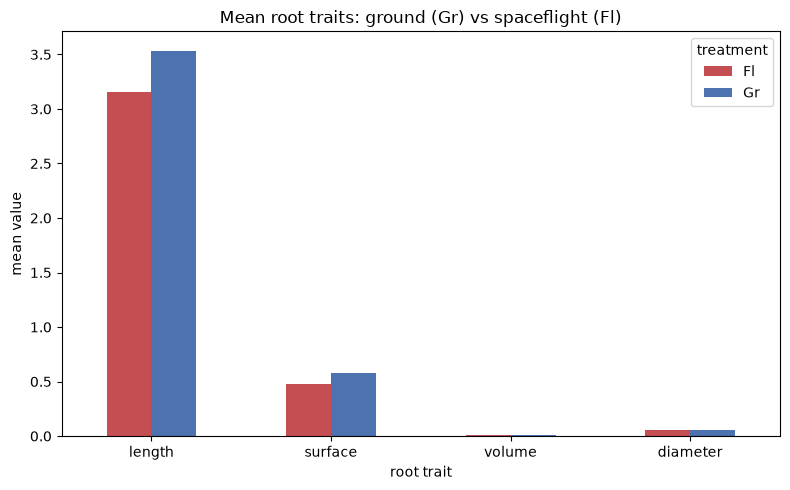

In [7]:
# a grouped bar chart of mean trait values: ground vs spaceflight
ax = group_means.T.plot(kind='bar', figsize=(8, 5),
                        color={'Gr': '#4C72B0', 'Fl': '#C44E52'})
ax.set_ylabel('mean value')
ax.set_xlabel('root trait')
ax.set_title('Mean root traits: ground (Gr) vs spaceflight (Fl)')
ax.legend(title='treatment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

*We will now examine the difference between ground and spaceflight samples for the distribution of each root trait: **length**, **surface**, **volume**, and **diameter**.*

## Root length: ground vs spaceflight

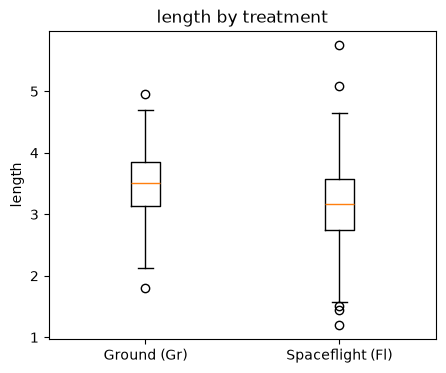

--- length  ---
  Ground (Gr):      n= 82  mean=3.5352  std=0.5769
  Spaceflight (Fl): n= 95  mean=3.1596  std=0.8136
  t-test:             p = 0.0004529
  Mann-Whitney U:     p = 0.0002526
  Kolmogorov-Smirnov: p = 0.0007715


In [8]:
# box plot and statistics for total root LENGTH
res_length = plotbox_and_stats(data['roots'], field='length')

## Root surface area: ground vs spaceflight

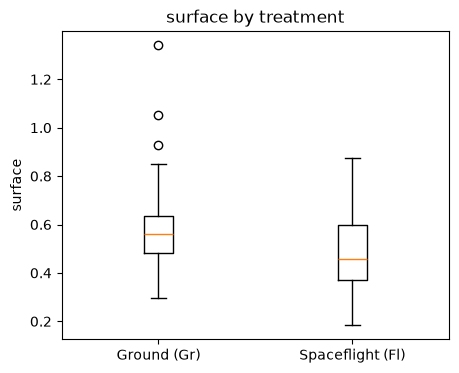

--- surface  ---
  Ground (Gr):      n= 82  mean=0.5764  std=0.1566
  Spaceflight (Fl): n= 95  mean=0.4777  std=0.1558
  t-test:             p = 4.436e-05
  Mann-Whitney U:     p = 1.723e-05
  Kolmogorov-Smirnov: p = 1.343e-06


In [9]:
# box plot and statistics for root SURFACE area
res_surface = plotbox_and_stats(data['roots'], field='surface')

## Root volume: ground vs spaceflight

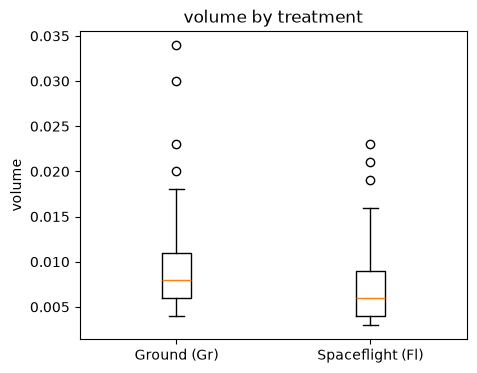

--- volume  ---
  Ground (Gr):      n= 82  mean=0.0095  std=0.0051
  Spaceflight (Fl): n= 95  mean=0.0075  std=0.0042
  t-test:             p = 0.005638
  Mann-Whitney U:     p = 0.000251
  Kolmogorov-Smirnov: p = 0.001374


In [10]:
# box plot and statistics for root VOLUME
res_volume = plotbox_and_stats(data['roots'], field='volume')

## Root diameter: ground vs spaceflight

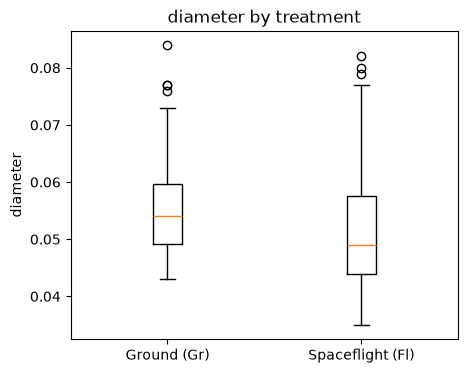

--- diameter  ---
  Ground (Gr):      n= 82  mean=0.0556  std=0.0086
  Spaceflight (Fl): n= 95  mean=0.0517  std=0.0115
  t-test:             p = 0.01155
  Mann-Whitney U:     p = 0.0008192
  Kolmogorov-Smirnov: p = 0.0001163


In [11]:
# box plot and statistics for root DIAMETER
res_diameter = plotbox_and_stats(data['roots'], field='diameter')

**QUESTIONS**

1. Which root traits showed a statistically significant difference (small p-value) between spaceflight and ground samples across all three tests?

2. Based on the box plots and the percent-change summary, does spaceflight tend to make roots larger or smaller overall?

3. Which single trait shows the most prominent distinction between spaceflight and ground samples?

# Does the spaceflight effect depend on ecotype/genotype?

Different *Arabidopsis* ecotypes and genotypes can respond to spaceflight differently. Here we break the **root length** comparison down by ecotype (`Col`, `WS`, `PhyD`, `Phy`) to see whether microgravity affects some genotypes more than others.

Spaceflight Treatment     Fl     Gr
Ecotype/Genotype                   
Col                    2.974  3.413
Phy                    3.415    NaN
PhyD                   3.071  3.494
WS                     3.390  3.744

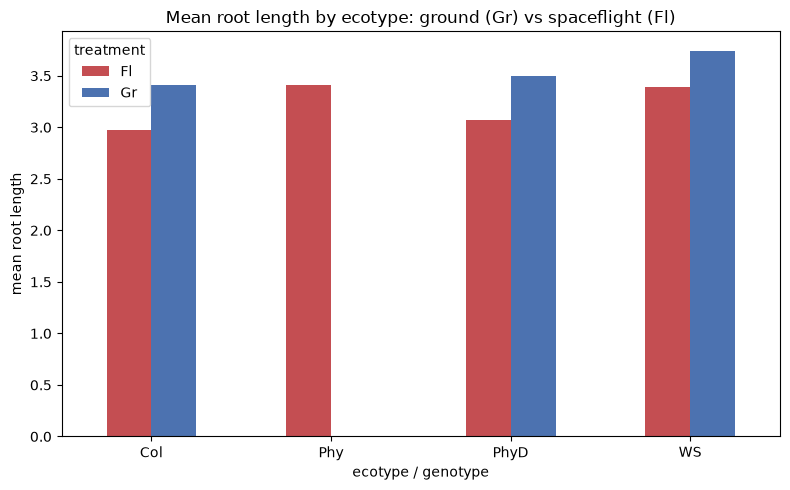

In [12]:
# mean root length by ecotype and treatment
by_eco = data['roots'].groupby(['Ecotype/Genotype', 'Spaceflight Treatment'])['length'].mean().unstack().round(3)
print(by_eco)

ax = by_eco.plot(kind='bar', figsize=(8, 5),
                 color={'Gr': '#4C72B0', 'Fl': '#C44E52'})
ax.set_ylabel('mean root length')
ax.set_xlabel('ecotype / genotype')
ax.set_title('Mean root length by ecotype: ground (Gr) vs spaceflight (Fl)')
ax.legend(title='treatment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

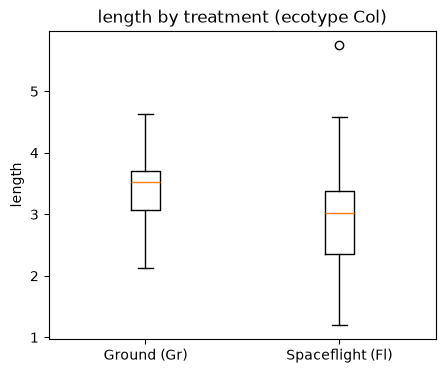

--- length (ecotype Col) ---
  Ground (Gr):      n= 29  mean=3.4127  std=0.5873
  Spaceflight (Fl): n= 33  mean=2.9745  std=0.9954
  t-test:             p = 0.03696
  Mann-Whitney U:     p = 0.01918
  Kolmogorov-Smirnov: p = 0.06369


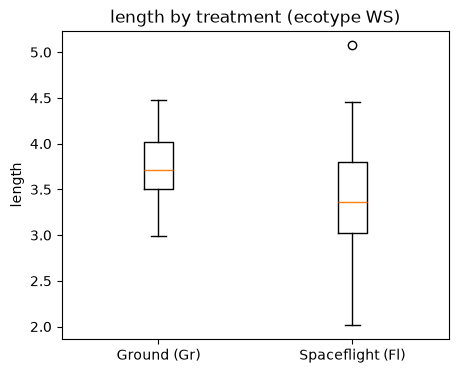

--- length (ecotype WS) ---
  Ground (Gr):      n= 23  mean=3.7438  std=0.4038
  Spaceflight (Fl): n= 31  mean=3.3896  std=0.6995
  t-test:             p = 0.02328
  Mann-Whitney U:     p = 0.01863
  Kolmogorov-Smirnov: p = 0.003322


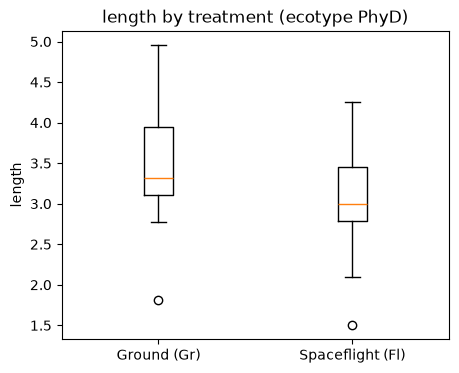

--- length (ecotype PhyD) ---
  Ground (Gr):      n= 30  mean=3.4938  std=0.6492
  Spaceflight (Fl): n= 26  mean=3.0711  std=0.5796
  t-test:             p = 0.01283
  Mann-Whitney U:     p = 0.01038
  Kolmogorov-Smirnov: p = 0.01391


In [13]:
# run the spaceflight-vs-ground length comparison separately within each ecotype
for eco in ['Col', 'WS', 'PhyD']:
    subset = data['roots'][data['roots']['Ecotype/Genotype'] == eco]
    plotbox_and_stats(subset, field='length', title_extra=f'(ecotype {eco})')

**QUESTIONS**

1. Which ecotype shows the largest reduction in root length under spaceflight?

2. Is the direction of the spaceflight effect (shorter vs longer roots) the same across all ecotypes?

3. Why might pooling all ecotypes together either strengthen or mask a real spaceflight effect?

# Does light condition modify the spaceflight effect?

CARA seedlings were grown under both **Light** and **Dark** conditions. Light is a powerful regulator of seedling development, so we ask whether the spaceflight effect on root length differs between illuminated and dark-grown plants.

Spaceflight Treatment        Fl     Gr
Illumination trestment 2              
Dark                      3.364  3.648
Light                     2.951  3.376


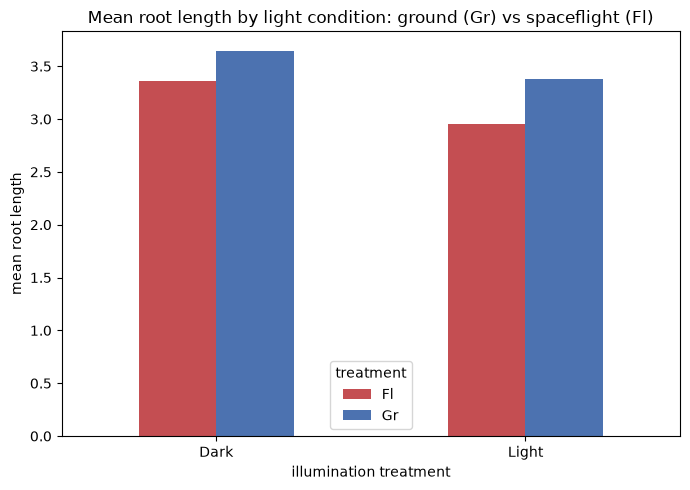

In [14]:
# mean root length by illumination and treatment
by_light = data['roots'].groupby(['Illumination trestment 2', 'Spaceflight Treatment'])['length'].mean().unstack().round(3)
print(by_light)

ax = by_light.plot(kind='bar', figsize=(7, 5),
                   color={'Gr': '#4C72B0', 'Fl': '#C44E52'})
ax.set_ylabel('mean root length')
ax.set_xlabel('illumination treatment')
ax.set_title('Mean root length by light condition: ground (Gr) vs spaceflight (Fl)')
ax.legend(title='treatment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

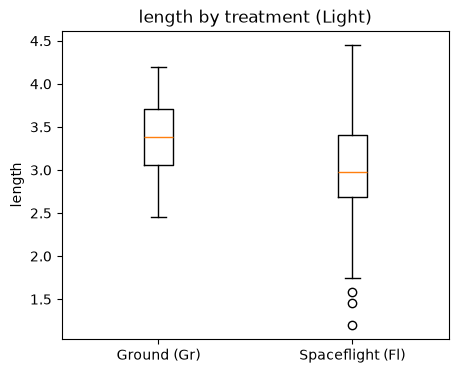

--- length (Light) ---
  Ground (Gr):      n= 34  mean=3.3757  std=0.4514
  Spaceflight (Fl): n= 47  mean=2.9511  std=0.7099
  t-test:             p = 0.001534
  Mann-Whitney U:     p = 0.004093
  Kolmogorov-Smirnov: p = 0.003866


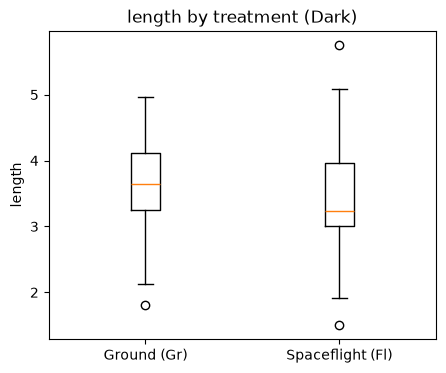

--- length (Dark) ---
  Ground (Gr):      n= 48  mean=3.6482  std=0.6317
  Spaceflight (Fl): n= 48  mean=3.3638  std=0.8629
  t-test:             p = 0.06875
  Mann-Whitney U:     p = 0.03676
  Kolmogorov-Smirnov: p = 0.03317


In [15]:
# run the spaceflight-vs-ground length comparison separately for Light and Dark
for light in ['Light', 'Dark']:
    subset = data['roots'][data['roots']['Illumination trestment 2'] == light]
    plotbox_and_stats(subset, field='length', title_extra=f'({light})')

**QUESTIONS**

1. Is the spaceflight reduction in root length more pronounced in the Light or in the Dark condition?

2. How could light partially substitute for the missing gravity cue in orbit?

3. How might you combine ecotype and light condition to build a model that predicts root length from growth environment?

# Summary

In this notebook we explored how spaceflight affects *Arabidopsis thaliana* root phenotypes using real CARA (OSD-120) measurements of 11-day-old seedlings:

- We loaded **177 individual root measurements** spanning spaceflight (`Fl`) and ground (`Gr`) treatments, multiple ecotypes, and light/dark illumination.
- We compared **length, surface area, volume, and diameter** between ground and spaceflight roots using box plots and three statistical tests (t-test, Mann-Whitney U, Kolmogorov-Smirnov).
- We broke the **root length** comparison down by **ecotype/genotype** and by **light condition** to see whether the spaceflight response depends on the plant's genetic background or its light environment.

These same techniques - load tabular phenotype data, summarize, visualize group differences, and test for significance - generalize to any spaceflight-versus-ground phenotype comparison in the OSDR archive.